In [26]:
from turtle import color
from typing import Optional
import pandas as pd
import numpy as np
from sympy import im
from datetime import datetime, timedelta
from scipy.stats import norm, t
import matplotlib.pyplot as plt 
import seaborn as sns
import sys

sys.path.append("..")

from detection.detection import HMMDetectionEngine
from dataPipeline.fetchData import DataPipeLine 

# Load Data

tech_sector_df = pd.read_csv("../data/tech_sector_xlk.csv")
tech_sector_df["returns"] = tech_sector_df["close"].pct_change()
tech_sector_df.dropna(inplace=True)
tech_sector_df["log_returns"] = np.log(1 + tech_sector_df["returns"])

energy_sector_df = pd.read_csv("../data/energy_sector_xlx.csv")
energy_sector_df["returns"] = energy_sector_df["close"].pct_change()
energy_sector_df.dropna(inplace=True)
energy_sector_df["log_returns"] = np.log(1 + energy_sector_df["returns"]) 

/var/folders/s_/7m7l27gn2bs9lqs5gyg9_hnw0000gn/T/ipykernel_12958/3154000716.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


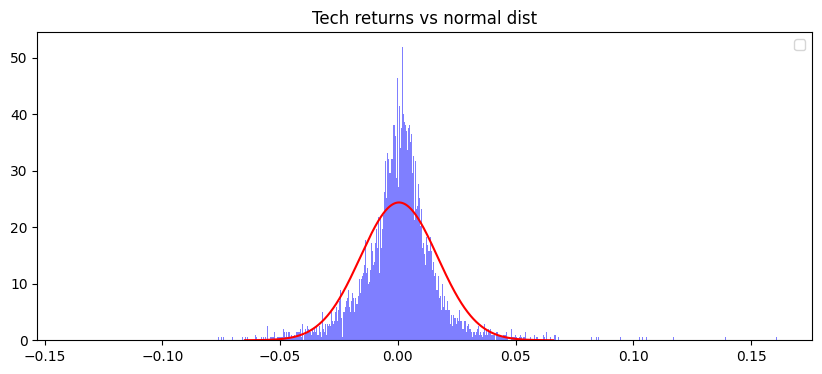

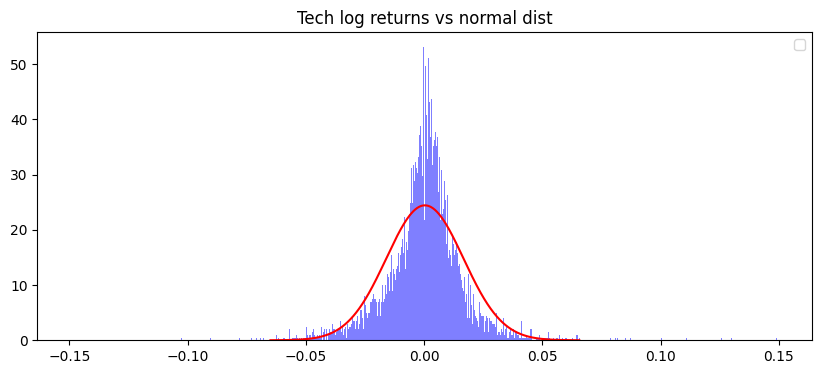

In [28]:
# Visualizing return, log returns and VaR
VaR_x = lambda df_series, percentile: -np.percentile(df_series, 100 - percentile)

def plot_against_normal(returns_series: pd.Series, title: str):
    plt.figure(figsize=(10,4))
    plt.hist(returns_series, bins=1000,
            color='blue', density=True, alpha=0.5)
    mu = returns_series.mean()
    sigma = returns_series.std()
    x = np.linspace(mu-4*sigma, mu+4*sigma, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma),
            color='red',
            )
    plt.title(title)
    plt.legend()
    plt.show()

# with returns 
plot_against_normal(tech_sector_df["returns"], "Tech returns vs normal dist")

# with log returns
plot_against_normal(tech_sector_df["log_returns"], "Tech log returns vs normal dist")


/var/folders/s_/7m7l27gn2bs9lqs5gyg9_hnw0000gn/T/ipykernel_12958/3154000716.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


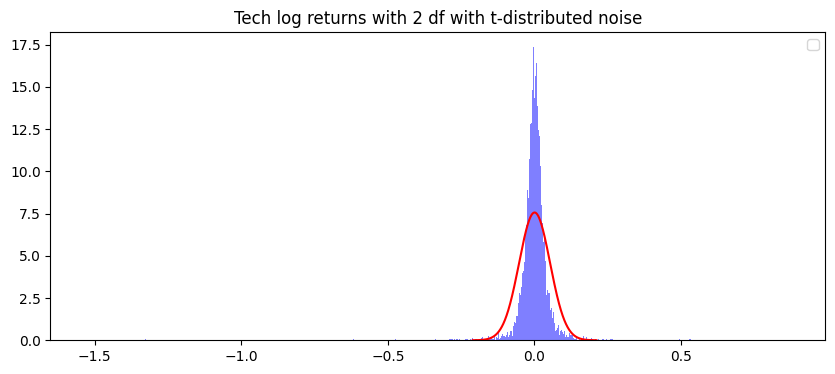

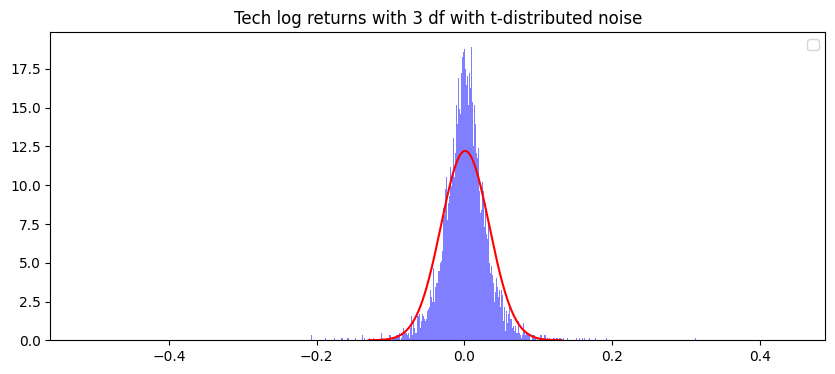

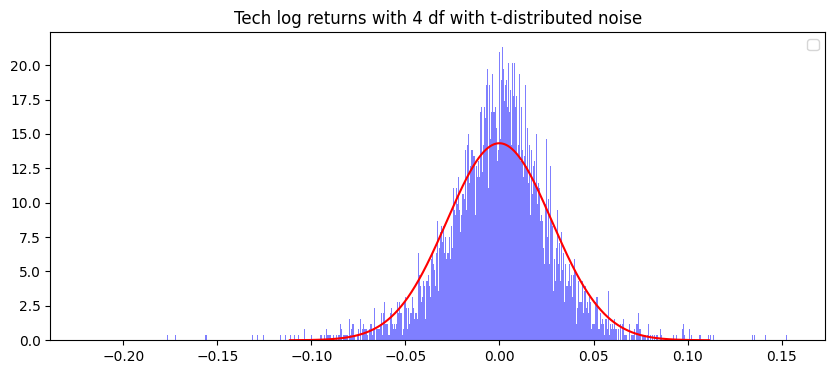

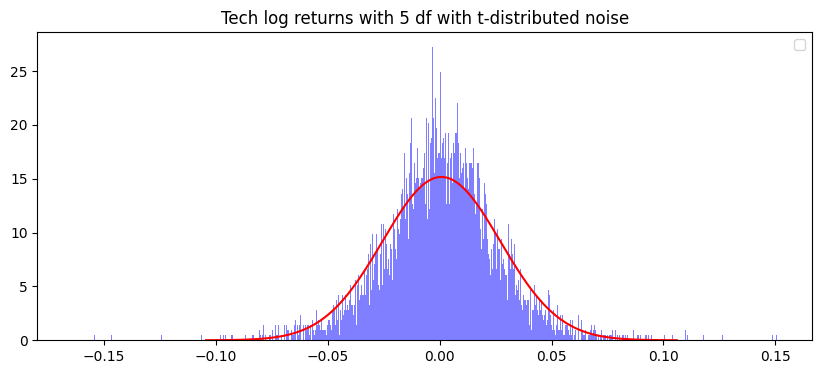

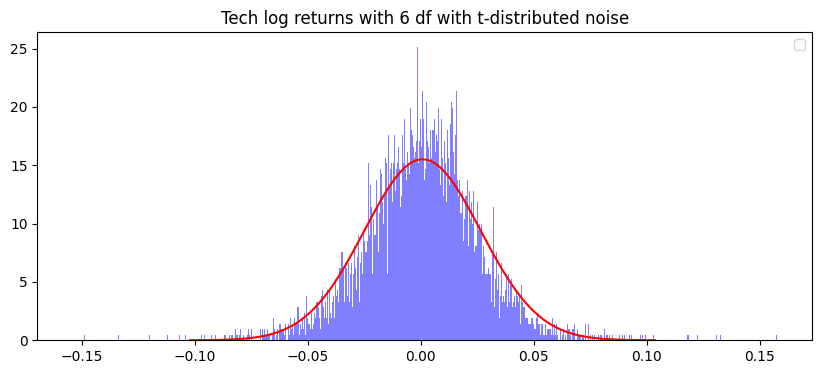

In [36]:

def plot_with_noise(series:pd.Series, title:str, degrees_freedom:int):
    mu = series.mean()
    sigma = series.std()
    simulated_noise = t.rvs(df=degrees_freedom, loc = mu, scale=sigma, size=len(series))
    new_series = series + simulated_noise
    plot_against_normal(new_series, title + " with t-distributed noise")

for df in range(2, 7):
    plot_with_noise(tech_sector_df["log_returns"], f"Tech log returns with {df} df", df)



From the plots above, we could see that adding noise does make a great difference for the fit, but still very innaccurate compared to the true observations especially around the tails. A regime switching model, would be able to give regime specific parameters which  make better approximation about how the returns behave. Financial returns often have fat tails which could not be captured using simple Gaussian distributions.

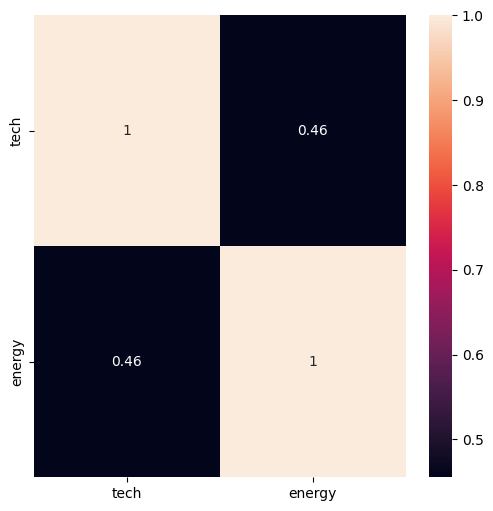

In [6]:
# correlation matrix

tech_returns = tech_sector_df[["date","returns"]].rename(columns={"returns":"tech"})
energy_returns = energy_sector_df[["date","returns"]].rename(columns={"returns":"energy"})
merged_returns = pd.merge(tech_returns, energy_returns, on="date")
corr_matrix = merged_returns[["tech", "energy"]].corr()

plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()